## Notebook for preprocessing of Joung2023 dataset

Step 0 (base dataset): Start from TFAtlas_subsample_raw

Step 1 (annotation enrichment), add: TF identity, is_differentiated, is_combinatorial_tested

Step 2 (balancing): QC, cap cells per TF (max 1000, min 1000, keep differentiated as much as possible) 

Step 3 (preprocessing): keep raw counts, normalize + log1p

Step 4 (controls): check whether to merge GFP and mCherry

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad
import scanpy as sc

In [2]:

adata_file = '../../../data/real/Joung2023/GSE217460_210322_TFAtlas_subsample_raw.h5ad'
adata_differentiated_file = '../../../data/real/Joung2023/GSE217460_210322_TFAtlas_differentiated_raw.h5ad'
adata_combinatorial_file = '../../../data/real/Joung2023/GSE217066_210715_combinatorial_subsample.h5ad'
result_folder = '../../../data/real/Joung2023/'
max_num_cells_per_tf = 1000

In [3]:
adata = sc.read_h5ad(adata_file)

In [4]:
adata

AnnData object with n_obs × n_vars = 671453 × 37528
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime'

In [5]:
adata.obs

,TF,batch,louvain,n_counts,n_genes,percent_mito,batchTF,score,temp,dpt_pseudotime,m3_pseudotime
"R1.07,R2.80,R3.02,P1.38-0-0",TFORF3021-DLX4,0,0,2875.0,2006,0.020870,0,-0.105044,TFORF3021-DLX4,0.011229,0.301840
"R1.08,R2.52,R3.41,P1.30-0-0",TFORF3021-DLX4,0,3,3529.0,2304,0.027203,0,0.948901,TFORF3021-DLX4,0.010818,0.103129
"R1.09,R2.21,R3.87,P1.30-0-0",TFORF3021-DLX4,0,1,4311.0,2706,0.022269,0,-0.021758,TFORF3021-DLX4,0.011743,0.086455
"R1.10,R2.84,R3.12,P1.46-0-0",TFORF3021-DLX4,0,4,1146.0,956,0.018325,0,1.254172,TFORF3021-DLX4,0.022796,0.340353
"R1.11,R2.84,R3.45,P1.46-0-0",TFORF3021-DLX4,0,1,4105.0,2698,0.024361,0,0.790120,TFORF3021-DLX4,0.010921,0.147176
...,...,...,...,...,...,...,...,...,...,...,...
"R1.29,R2.64,R3.18,P1.62-3-1",TFORF3469-ZNF438,1,6,5425.0,3217,0.019539,3265,1.128558,TFORF3469-ZNF438,0.427166,0.623152
"R1.36,R2.31,R3.09,P1.62-3-1",TFORF3469-ZNF438,1,3,4342.0,2734,0.020037,3265,1.631460,TFORF3469-ZNF438,0.010961,0.167478
"R1.52,R2.33,R3.67,P1.62-3-1",TFORF3469-ZNF438,1,6,10564.0,4857,0.013537,3265,0.365121,TFORF3469-ZNF438,0.719953,0.623152
"R1.87,R2.35,R3.24,P1.62-3-1",TFORF3469-ZNF438,1,3,3641.0,2439,0.015930,3265,0.518624,TFORF3469-ZNF438,0.011047,0.094934


In [6]:
adata.obs[['ORF_ID', 'TF_name']]= adata.obs['TF'].str.split('-', n=1, expand=True)

In [7]:
adata.obs['tmp'] = adata.obs['TF_name'] + '_' + adata.obs['batch'].astype(str) 
tmp = adata.obs['tmp'].value_counts().reset_index()
tmp[['TF', 'batch']] = tmp['tmp'].str.split('_', n=1, expand=True)
tmp.to_csv('output.csv')

In [8]:
adata_differentiated = sc.read_h5ad(adata_differentiated_file)
adata_combinatorial = sc.read_h5ad(adata_combinatorial_file)

In [9]:
adata.obs['is_differentiated'] = adata.obs_names.isin(adata_differentiated.obs_names)

In [10]:
adata_combinatorial = adata_combinatorial[adata_combinatorial.obs['TF'].str.count(',') == 1, :]
adata_combinatorial.obs[['TF1', 'TF2']] = adata_combinatorial.obs['TF'].str.split(',', n=1, expand=True)
adata_combinatorial.obs[['ORF_ID1', 'TF_name1']] = adata_combinatorial.obs['TF1'].str.split('-', n=1, expand=True)
adata_combinatorial.obs[['ORF_ID2', 'TF_name2']] = adata_combinatorial.obs['TF2'].str.split('-', n=1, expand=True)
adata_combinatorial.obs['TF_name'] = adata_combinatorial.obs['TF_name1'] + '+' + adata_combinatorial.obs['TF_name2']
double_intervened_tfs = list(set(adata_combinatorial.obs['TF_name1'].unique()).union(set(adata_combinatorial.obs['TF_name2'].unique())))


/tmp/ipykernel_1137110/1893433220.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_combinatorial.obs[['TF1', 'TF2']] = adata_combinatorial.obs['TF'].str.split(',', n=1, expand=True)


In [11]:
adata.obs['is_combinatorially_tested'] = adata.obs['TF_name'].isin(double_intervened_tfs)
adata.obs['is_combinatorially_tested'].sum()

np.int64(11725)

In [15]:
adata_combinatorial.var_names.isin(adata.var_names).sum()

np.int64(10096)

In [17]:
tmp = ad.read_h5ad('../../../data/real/Joung2023/' + 'Joung2023.h5ad')

In [19]:
tmp.var_names.isin(adata_combinatorial.var_names).sum()

np.int64(1693)

In [ ]:
# adding columns
adata.obs['dataset'] = 'single'
adata_combinatorial.obs['dataset'] = 'double'
adata_combinatorial.obs['is_differentiated'] = False
adata_combinatorial.obs['is_combinatorially_tested'] = True


# merging the combinatorial data with the main adata
adata.obs = adata.obs.loc[:, ['TF', 'n_counts', 'n_genes', 'percent_mito', 'ORF_ID', 'TF_name', 'batch', 'dataset', 'is_differentiated', 'is_combinatorially_tested']].copy()
adata.obs = adata.obs.loc[:, ['TF', 'n_counts', 'n_genes', 'percent_mito', 'ORF_ID', 'TF_name', 'batch', 'dataset', 'is_differentiated', 'is_combinatorially_tested']].copy()

In [31]:
adata.obs.loc[:, ['n_counts', 'n_genes', 'percent_mito']].agg(['min', 'max'], numeric_only=True)

,n_counts,n_genes,percent_mito
min,769.0,700,0.002822
max,14973.0,5915,0.049968


In [32]:
tf_name_counts = adata.obs['TF_name'].value_counts()
to_remove = tf_name_counts[tf_name_counts < 100].index
adata = adata[~adata.obs['TF_name'].isin(to_remove), :]

In [36]:
diff_stats = adata.obs.groupby('TF_name')['is_differentiated'].agg(['sum', 'count'])
diff_stats.columns = ['n_differentiated', 'n_total']
diff_stats['n_non_differentiated'] = diff_stats['n_total'] - diff_stats['n_differentiated']
diff_stats['frac_differentiated'] = diff_stats['n_differentiated'] / diff_stats['n_total']

all_diff = (diff_stats['n_non_differentiated'] == 0).sum()
all_non_diff = (diff_stats['n_differentiated'] == 0).sum()
mixed = ((diff_stats['n_differentiated'] > 0) & (diff_stats['n_non_differentiated'] > 0)).sum()

print(f"TFs with ALL cells differentiated:     {all_diff}")
print(f"TFs with NO cells differentiated:      {all_non_diff}")
print(f"TFs with MIXED differentiation status: {mixed}")
#diff_stats.sort_values('frac_differentiated', ascending=False)
diff_stats.sort_values('n_differentiated', ascending=False)

TFs with ALL cells differentiated:     0
TFs with NO cells differentiated:      0
TFs with MIXED differentiation status: 862


,n_differentiated,n_total,n_non_differentiated,frac_differentiated
TF_name,,,,
KLF5,704,1913,1209,0.368008
CREM,498,12649,12151,0.039371
PAX5,481,4145,3664,0.116043
KLF2,408,1000,592,0.408000
KLF1,347,1000,653,0.347000
...,...,...,...,...
ERF,1,122,121,0.008197
NFIL3,1,164,163,0.006098
NF1,1,112,111,0.008929


In [37]:
def subsample_tf(group, max_cells, seed=42):
    if len(group) <= max_cells:
        return group
    differentiated = group[group['is_differentiated']]
    non_differentiated = group[~group['is_differentiated']]
    n_diff = min(len(differentiated), max_cells)
    selected = [differentiated.sample(n=n_diff, random_state=seed)]
    remaining = max_cells - n_diff
    if remaining > 0:
        selected.append(non_differentiated.sample(n=min(remaining, len(non_differentiated)), random_state=seed))
    return pd.concat(selected)

keep_idx = (
    adata.obs
    .groupby('TF_name', group_keys=False)
    .apply(lambda g: subsample_tf(g, max_num_cells_per_tf))
    .index
)
adata = adata[keep_idx, :]
print(adata.obs['TF_name'].value_counts().describe())

count     862.000000
mean      534.754060
std       348.023818
min       100.000000
25%       210.250000
50%       419.000000
75%      1000.000000
max      1000.000000
Name: count, dtype: float64


/tmp/ipykernel_1044503/2249754312.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: subsample_tf(g, max_num_cells_per_tf))


In [39]:
# Store raw counts before any normalization
adata.layers['counts'] = adata.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store normalized+log1p before HVG subsetting and scaling
adata.layers['lognorm'] = adata.X.copy()

# HVG selection on normalized+log data
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key='batch', subset=False)
print(f"HVGs selected: {adata.var['highly_variable'].sum()}")

# Limit to HVGs for PCA
adata = adata[:, adata.var['highly_variable']]

# Scale and run PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50, svd_solver='arpack')

# Restore X to lognorm values (HVG subset)
adata.X = adata.layers['lognorm'].copy()

# UMAP (via neighbors graph)
sc.pp.neighbors(adata, n_pcs=50)
sc.tl.umap(adata)

adata

/tmp/ipykernel_1044503/3037685592.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy()


HVGs selected: 5000


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 460958 × 5000
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'ORF_ID', 'TF_name', 'tmp', 'is_differentiated', 'is_combinatorially_tested'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'distances', 'connectivities'

## Step 4: Controls — check mCherry vs GFP overlap on UMAP

In [ ]:
import matplotlib.pyplot as plt

controls = ['mCherry', 'GFP']
adata_ctrl = adata[adata.obs['TF_name'].isin(controls)]
print(adata_ctrl.obs['TF_name'].value_counts())

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'mCherry': '#B8860B', 'GFP': '#006400'}
for tf, grp in adata_ctrl.obs.groupby('TF_name'):
    umap_coords = adata_ctrl[grp.index].obsm['X_umap']
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1],
               c=colors[tf], label=tf, s=3, alpha=0.5)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend(markerscale=4)
ax.set_title('UMAP — mCherry vs GFP controls')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1044503/3234405918.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diff_frac = adata.obs.groupby('TF_name')['is_differentiated'].mean()
/tmp/ipykernel_1044503/3234405918.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', len(selected_tfs))
/tmp/ipykernel_1044503/3234405918.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for tf, grp in adata_plot.obs.groupby('TF_name'):


Plotting 40 groups: controls + 38 TFs


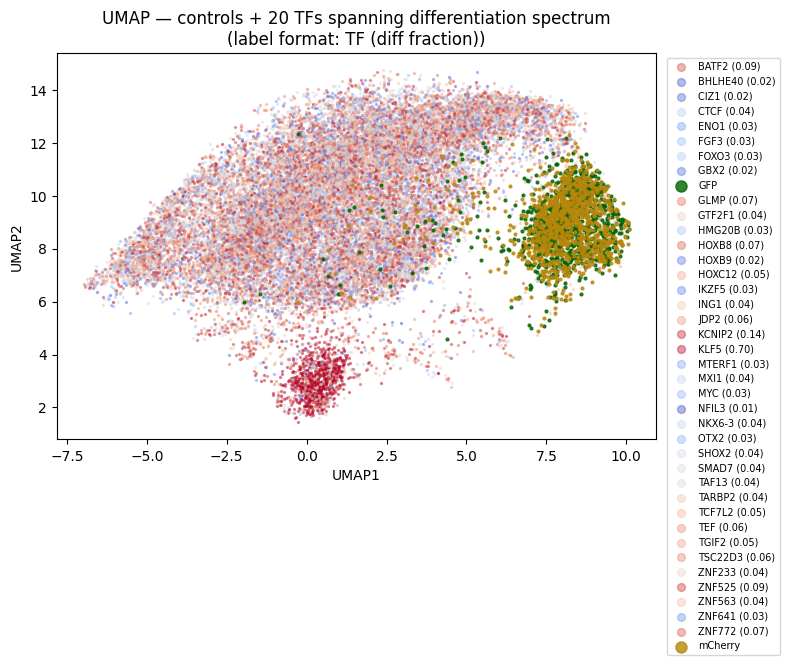

In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Select 20 TFs spanning the full range of differentiation fraction
diff_frac = adata.obs.groupby('TF_name')['is_differentiated'].mean()
diff_frac = diff_frac.drop(labels=['mCherry', 'GFP'], errors='ignore')
selected_tfs = diff_frac.quantile(np.linspace(0, 1, 20), interpolation='nearest').drop_duplicates().values.tolist()
selected_tfs = diff_frac[diff_frac.isin(selected_tfs)].index.tolist()
plot_tfs = ['mCherry', 'GFP'] + selected_tfs
print(f"Plotting {len(plot_tfs)} groups: controls + {len(selected_tfs)} TFs")

adata_plot = adata[adata.obs['TF_name'].isin(plot_tfs)]

# Color controls distinctly; TFs by a continuous colormap based on diff fraction
cmap = cm.get_cmap('coolwarm', len(selected_tfs))
tf_colors = {tf: cmap(i) for i, tf in enumerate(sorted(selected_tfs, key=lambda t: diff_frac[t]))}
tf_colors['mCherry'] = '#B8860B'  # dark yellow
tf_colors['GFP'] = '#006400'      # dark green

fig, ax = plt.subplots(figsize=(8, 6))
for tf, grp in adata_plot.obs.groupby('TF_name'):
    coords = adata_plot[grp.index].obsm['X_umap']
    is_control = tf in ('mCherry', 'GFP')
    frac = diff_frac.get(tf, float('nan'))
    label = tf if is_control else f"{tf} ({frac:.2f})"
    ax.scatter(coords[:, 0], coords[:, 1],
               c=[tf_colors[tf]], label=label,
               s=4 if is_control else 2,
               alpha=0.8 if is_control else 0.4,
               zorder=3 if is_control else 1)

ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('UMAP — controls + 20 TFs spanning differentiation spectrum\n(label format: TF (diff fraction))')
ax.legend(markerscale=4, fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
adata.obs['control_type'] = adata.obs['TF_name'].where(adata.obs['TF_name'].isin(['mCherry', 'GFP']), other=None)
adata.obs['TF_name'] = adata.obs['TF_name'].replace({'mCherry': 'ctrl', 'GFP': 'ctrl'})

print(adata.obs['control_type'].value_counts(dropna=False))
print(adata.obs['TF_name'].value_counts().head())

control_type
NaN        458958
GFP          1000
mCherry      1000
SOX15           0
SOX30           0
            ...  
JUN             0
JUNB            0
JUND            0
KAT7            0
IRF6            0
Name: count, Length: 863, dtype: int64
TF_name
ctrl      2000
ASCL4     1000
ZSCAN9    1000
ATF3      1000
ZNF717    1000
Name: count, dtype: int64


/tmp/ipykernel_1044503/3069048171.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['TF_name'] = adata.obs['TF_name'].replace({'mCherry': 'ctrl', 'GFP': 'ctrl'})


In [48]:
adata.write_h5ad(result_folder + 'Joung2023.h5ad')
print(f"Saved to {result_folder}Joung2023.h5ad")

Saved to ../../../data/real/Joung2023/Joung2023.h5ad


In [6]:
# loading the data back
adata = sc.read_h5ad(result_folder + 'Joung2023.h5ad')